<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/11a_jax.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

(nutpie-intro-notebook)=
# Nutpie e Stan

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import jax
import pymc.sampling_jax
import nutpie
import scipy.stats as stats
import seaborn as sns
import arviz as az
import warnings

/Users/corrado/opt/anaconda3/envs/nutpie_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
sns.set_theme(palette="colorblind")

In [24]:
code = """
data {
    int<lower=0> N;
    array[N] int<lower=0,upper=1> y;
}
    parameters {
    real<lower=0,upper=1> theta;
}
model {
    theta ~ beta(1,1);  // uniform prior on interval 0,1
    y ~ bernoulli(theta);
}
generated quantities {
    array[N] int<lower=0, upper=1> y_rep; // generated data for posterior predictive checks
    array[N] real log_lik; // log likelihood for each observation

    for (n in 1:N) {
        y_rep[n] = bernoulli_rng(theta); // simulate new data based on posterior of theta
        log_lik[n] = bernoulli_lpmf(y[n] | theta); // calculate log likelihood for each observed data point
    }
}
"""

In [25]:
compiled = nutpie.compile_stan_model(code=code)

In [26]:
compiled = compiled.with_data(
    N=10,
    y=[1, 1, 1, 0,0,0,0,0,0,0]
)

In [27]:
trace = nutpie.sample(compiled)

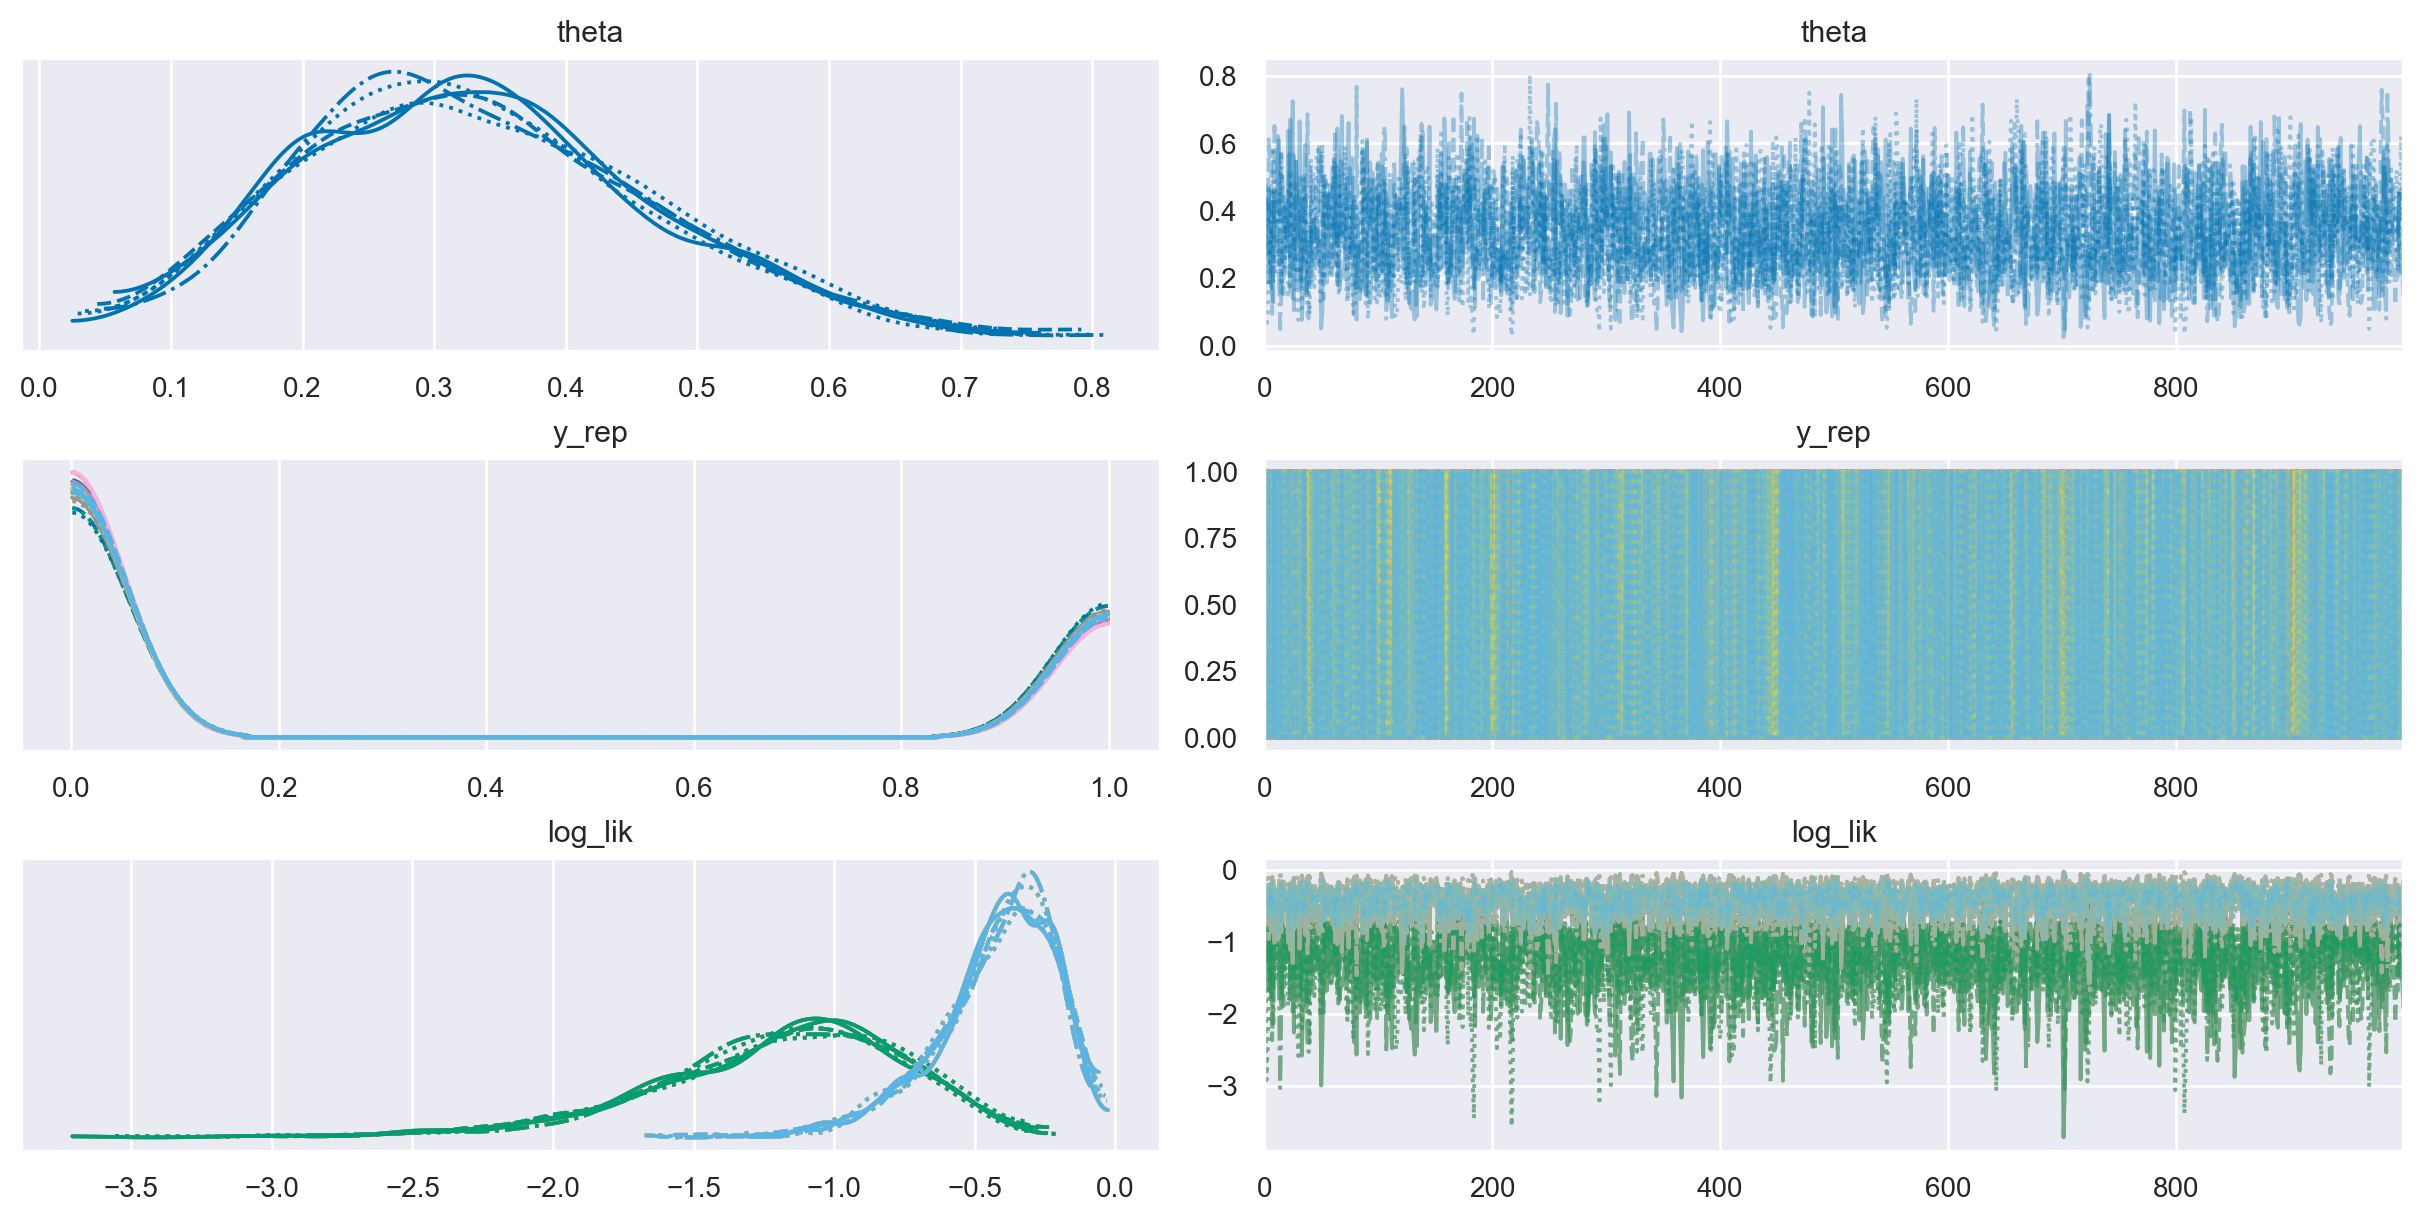

In [33]:
_ = az.plot_trace(trace)

In [8]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.335,0.128,0.107,0.575,0.003,0.002,2406.0,3329.0,1.0


## Watermark

In [9]:
%load_ext watermark
%watermark -n -u -v -iv -w -p nutpie -m

Last updated: Thu Feb 22 2024

Python implementation: CPython
Python version       : 3.11.8
IPython version      : 8.22.0

nutpie: 0.9.2

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.3.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

numpy     : 1.26.4
pymc      : 5.10.4
arviz     : 0.17.0
seaborn   : 0.13.2
scipy     : 1.12.0
matplotlib: 3.8.3
jax       : 0.4.23
nutpie    : 0.9.2

Watermark: 2.4.3

